# Example of peak detection

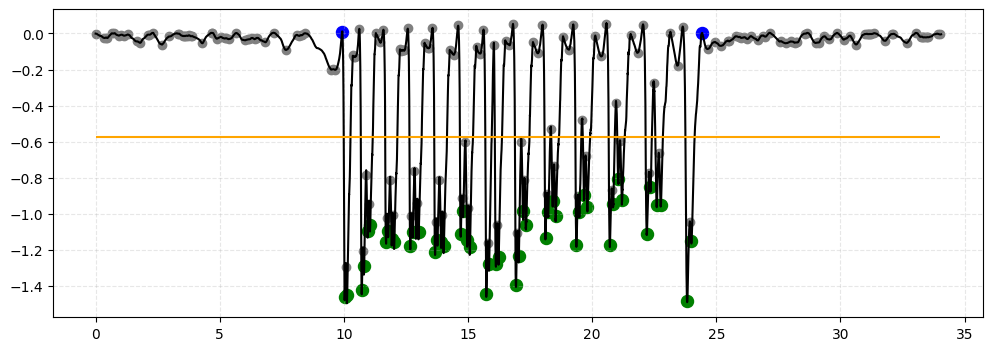

In [1]:
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
import os
from pathlib import Path

d = Path.cwd()
if d == Path('C:/git/RailwAI/code'):
    root = d.parent
elif d == Path('C:/git/RailwAI'):
    root = d
else:
    print('ERROR: you are actually in ' + str(Path.cwd()))

file = root / 'files/example_peak_detection/ADTC_8_adz_raw_20260304_1920.csv'

df = pd.read_csv(file)
time = df['Time [s]'].values
signal = df['Distance[mm]'].values

# sampling frequency
fs = 1/np.mean(np.diff(time))
signal_smooth = savgol_filter(signal, 101, 3)

# peak detection
from utils import peakFind, thresholdValue, firstLastPeak, downPeak
peakValues, peakTimes = peakFind(time, signal_smooth, fs)
firstValue, firstTime, lastValue, lastTime = firstLastPeak(peakValues, peakTimes)
downValues, downTimes = downPeak(peakValues, peakTimes)
threshold = thresholdValue(peakValues)

# plot
plt.figure(figsize=(12, 4))
plt.plot(df["Time [s]"], df["Distance[mm]"], linestyle='-', c='k')
plt.hlines(threshold ,peakTimes[0], peakTimes[-1], color='orange')
plt.scatter(peakTimes, peakValues, c='gray')
plt.scatter(firstTime, firstValue, s=75, c='b')
plt.scatter(lastTime, lastValue, s=75, c='b')
plt.scatter(downTimes, downValues, s=75, c='g')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()